<a href="https://colab.research.google.com/github/aniray2908/satellite-esg-risk-engine/blob/main/experiments/python/comparative_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3 — Comparative Environmental Exposure Analysis

This notebook compares satellite-derived vegetation exposure metrics across:

- Carajás Mine (Brazil)
- Gevra Coal Mine (India)

The objective is to evaluate cross-site generalization of the validated exposure pipeline.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

carajas_path = "/content/drive/MyDrive/carajas_pit_centered_full_year_v2_1.csv"
gevra_path = "/content/drive/MyDrive/gevra_pit_centered_full_year_v1.csv"

carajas = pd.read_csv(carajas_path).sort_values("year")
gevra = pd.read_csv(gevra_path).sort_values("year")

carajas.head(), gevra.head()

(   system:index  image_count  low_ndvi_fraction  mean_ndvi  year  \
 0             0          101           0.865651   0.059416  2019   
 1             1           84           0.921274   0.058572  2020   
 2             2           89           0.974743   0.012760  2021   
 3             3           83           0.954150   0.029671  2022   
 4             4           95           0.970843   0.015329  2023   
 
                                      .geo  
 0  {"type":"MultiPoint","coordinates":[]}  
 1  {"type":"MultiPoint","coordinates":[]}  
 2  {"type":"MultiPoint","coordinates":[]}  
 3  {"type":"MultiPoint","coordinates":[]}  
 4  {"type":"MultiPoint","coordinates":[]}  ,
    system:index  image_count  low_ndvi_fraction  mean_ndvi  year  \
 0             0           53           0.684274   0.167039  2019   
 1             1           47           0.674309   0.219607  2020   
 2             2           54           0.696118   0.180289  2021   
 3             3           57        

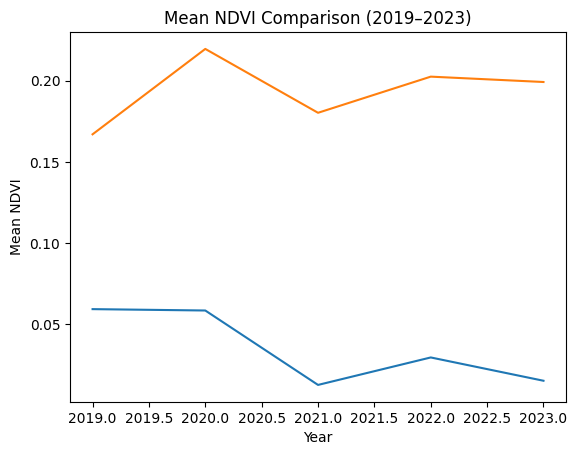

In [3]:
plt.figure()
plt.plot(carajas["year"], carajas["mean_ndvi"])
plt.plot(gevra["year"], gevra["mean_ndvi"])

plt.title("Mean NDVI Comparison (2019–2023)")
plt.xlabel("Year")
plt.ylabel("Mean NDVI")

plt.savefig("comparison_mean_ndvi.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation — Mean NDVI

Carajás exhibits near-zero mean NDVI across all years,
indicating persistent exposed mining footprint.

Gevra shows higher mean NDVI (~0.17–0.22),
reflecting partial vegetation presence within the 1 km buffer.

This demonstrates that the pipeline distinguishes exposure intensity across sites.


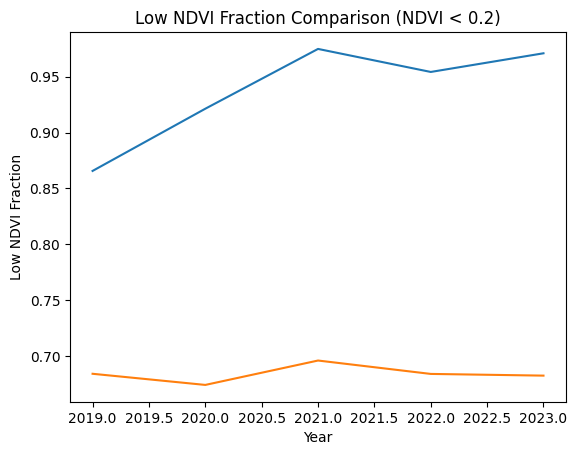

In [4]:
plt.figure()
plt.plot(carajas["year"], carajas["low_ndvi_fraction"])
plt.plot(gevra["year"], gevra["low_ndvi_fraction"])

plt.title("Low NDVI Fraction Comparison (NDVI < 0.2)")
plt.xlabel("Year")
plt.ylabel("Low NDVI Fraction")

plt.savefig("comparison_low_ndvi_fraction.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation — Low NDVI Fraction

Carajás maintains extremely high exposure levels (~0.95),
indicating dominant bare surface within the pit-centered buffer.

Gevra shows moderate exposure (~0.68–0.70),
suggesting mixed excavation and vegetated areas.

The contrast confirms cross-site generalization
and demonstrates that environmental exposure intensity varies by asset.


In [5]:
summary = pd.DataFrame({
    "Site": ["Carajás", "Gevra"],
    "Avg Mean NDVI": [
        carajas["mean_ndvi"].mean(),
        gevra["mean_ndvi"].mean()
    ],
    "Avg Low NDVI Fraction": [
        carajas["low_ndvi_fraction"].mean(),
        gevra["low_ndvi_fraction"].mean()
    ]
})

summary

,Site,Avg Mean NDVI,Avg Low NDVI Fraction
0,Carajás,0.035150,0.937332
1,Gevra,0.193744,0.684294


## Comparative Conclusion

The satellite-derived exposure pipeline:

- Generalizes across continents (South America, India)
- Generalizes across mineral types (Iron Ore, Coal)
- Produces stable multi-year signals
- Differentiates exposure intensity across assets

Carajás represents high-intensity persistent exposure.
Gevra represents moderate but stable industrial footprint.

This establishes the foundation for a structured
satellite-derived risk scoring framework.
